Peringatan: File data/dataset/telco_customer_churn.csv tidak ditemukan!
Sistem membuat Dataset Simulasi (Mock Data) secara otomatis agar program tetap berjalan...
Dataset Simulasi berhasil dibuat!

--- 1. DATA UNDERSTANDING & CLEANING ---
Melihat 5 baris pertama data:
  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   CUST0000    Male              0      No         No      50          Yes   
1   CUST0001  Female              0      No        Yes      46          Yes   
2   CUST0002    Male              0      No        Yes       3          Yes   
3   CUST0003    Male              0      No        Yes       6          Yes   
4   CUST0004    Male              0     Yes         No      34          Yes   

  InternetService  MonthlyCharges        TotalCharges Churn  
0              No          115.22              5761.0    No  
1              No           91.36             4202.56   Yes  
2             DSL          112.88              338.64   Yes  
3       

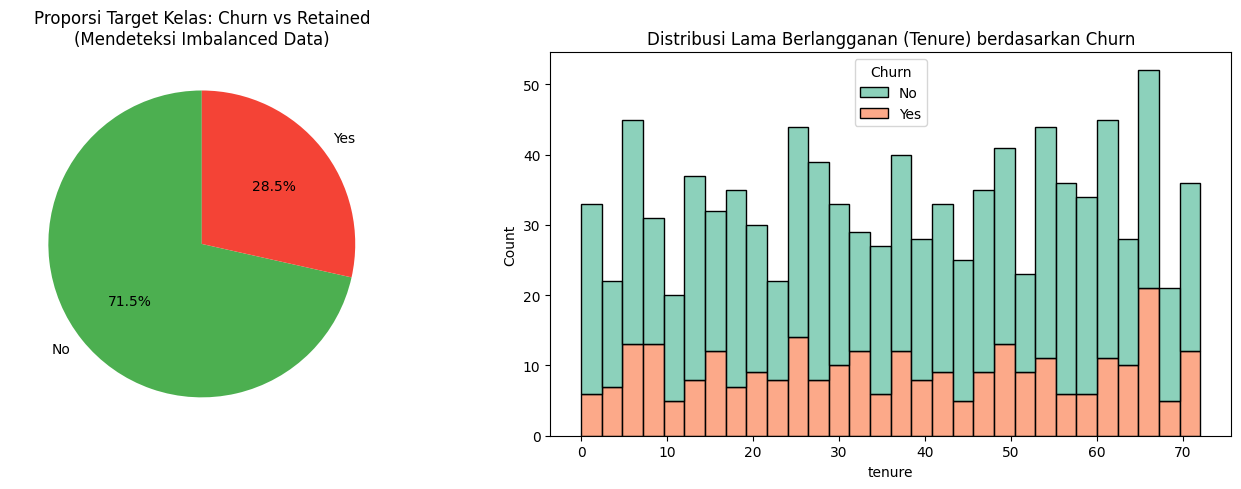

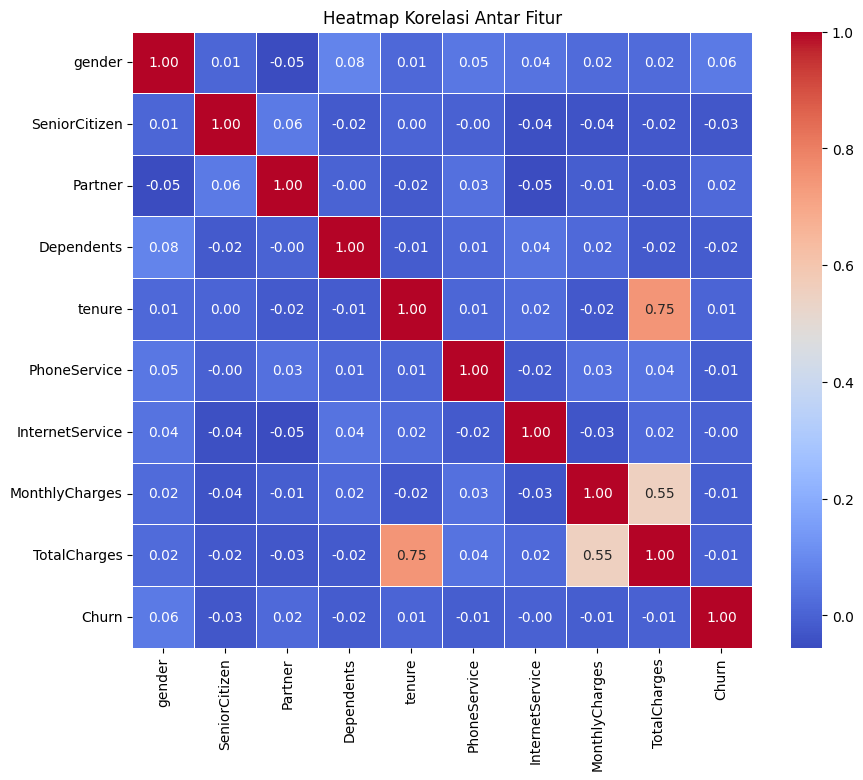


--- 3. DATA PREPARATION ---
Encoding data kategorik selesai.
Normalisasi data numerik menggunakan StandardScaler selesai.
Data split berhasil: 800 data latih, 200 data uji.

--- 4. MODELING ---
Model Decision Tree berhasil dilatih.
Model K-Nearest Neighbors (KNN) berhasil dilatih.


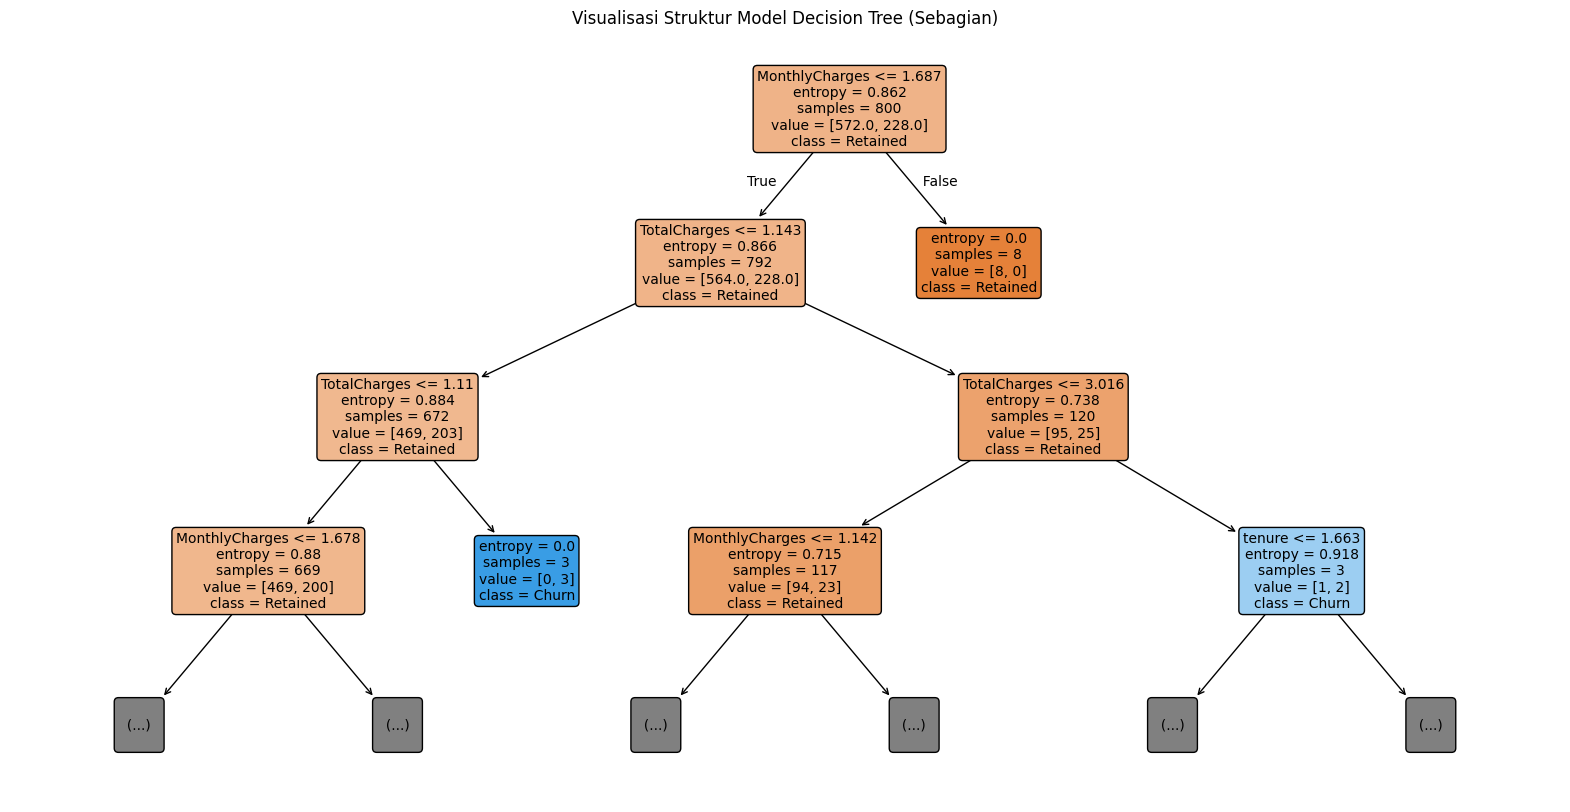


--- 5. EVALUATION ---

>> Hasil Evaluasi: Decision Tree <<
Confusion Matrix:
[[141   2]
 [ 56   1]]
Accuracy  : 0.7100 (Persentase prediksi benar secara keseluruhan)
Precision : 0.3333 (Ketepatan memprediksi kelas Churn)
Recall    : 0.0175 (Kemampuan mendeteksi semua yang benar-benar Churn)
F1-Score  : 0.0333 (Keseimbangan antara Precision dan Recall)

>> Hasil Evaluasi: K-Nearest Neighbors <<
Confusion Matrix:
[[124  19]
 [ 51   6]]
Accuracy  : 0.6500 (Persentase prediksi benar secara keseluruhan)
Precision : 0.2400 (Ketepatan memprediksi kelas Churn)
Recall    : 0.1053 (Kemampuan mendeteksi semua yang benar-benar Churn)
F1-Score  : 0.1463 (Keseimbangan antara Precision dan Recall)

--- KESIMPULAN PERBANDINGAN MODEL ---
   Metrik  Decision Tree      KNN
 Accuracy       0.710000 0.650000
Precision       0.333333 0.240000
   Recall       0.017544 0.105263
 F1-Score       0.033333 0.146341

Berdasarkan metrik Akurasi, model terbaik untuk percobaan ini adalah Decision Tree.
Catatan untuk

In [1]:
# %%
"""
Proyek UAS Kecerdasan Buatan: Prediksi Customer Churn
Pastikan untuk menjalankan kode ini di environment Jupyter Notebook atau Google Colab.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Mengabaikan peringatan agar output rapi

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# %%
# Mencoba memuat dataset dari direktori yang disyaratkan
file_path = 'data/dataset/telco_customer_churn.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"Peringatan: File {file_path} tidak ditemukan!")
    print("Sistem membuat Dataset Simulasi (Mock Data) secara otomatis agar program tetap berjalan...")

    # Membuat 1000 data simulasi yang menyerupai dataset Telco Churn
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'customerID': [f'CUST{i:04d}' for i in range(n_samples)],
        'gender': np.random.choice(['Male', 'Female'], n_samples),
        'SeniorCitizen': np.random.choice([0, 1], n_samples, p=[0.85, 0.15]),
        'Partner': np.random.choice(['Yes', 'No'], n_samples),
        'Dependents': np.random.choice(['Yes', 'No'], n_samples),
        'tenure': np.random.randint(0, 73, n_samples),
        'PhoneService': np.random.choice(['Yes', 'No'], n_samples, p=[0.9, 0.1]),
        'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples),
        'MonthlyCharges': np.round(np.random.uniform(18.0, 120.0, n_samples), 2),
        'TotalCharges': np.nan, # Akan diisi berdasarkan tenure * MonthlyCharges
        'Churn': np.random.choice(['Yes', 'No'], n_samples, p=[0.27, 0.73]) # Rasio imbalanced
    })

    # Menyimulasikan nilai TotalCharges (ada yang berisi string kosong agar bisa dibersihkan nanti)
    df['TotalCharges'] = (df['tenure'] * df['MonthlyCharges']).astype(str)
    blank_indices = np.random.choice(df.index, 5, replace=False)
    df.loc[blank_indices, 'TotalCharges'] = ' '
    print("Dataset Simulasi berhasil dibuat!")

# %%
print("\n--- 1. DATA UNDERSTANDING & CLEANING ---")
print("Melihat 5 baris pertama data:")
print(df.head())

# Drop kolom customerID karena tidak relevan untuk machine learning
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Membersihkan spasi kosong pada 'TotalCharges' (masalah umum pada dataset Telco Churn)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))

# Cek dan tangani Missing Values (Null)
missing_values = df.isnull().sum().sum()
if missing_values > 0:
    print(f"Ditemukan {missing_values} nilai null pada TotalCharges. Mengisi dengan nilai Median.")
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
else:
    print("Tidak ditemukan nilai null pada data.")

# Cek duplikasi
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Ditemukan {duplicates} data duplikat. Menghapus duplikasi...")
    df.drop_duplicates(inplace=True)

# %%
print("\n--- 2. EXPLORATORY DATA ANALYSIS (EDA) ---")

plt.figure(figsize=(14, 5))

# 1. Pie Chart untuk Deteksi Data Tidak Seimbang (Imbalanced Classes)
plt.subplot(1, 2, 1)
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
plt.title('Proporsi Target Kelas: Churn vs Retained\n(Mendeteksi Imbalanced Data)')

# 2. Histogram untuk Distribusi Data Numerik (Tenure)
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, palette='Set2')
plt.title('Distribusi Lama Berlangganan (Tenure) berdasarkan Churn')

plt.tight_layout()
plt.show()

# %%
# Untuk melihat korelasi fitur, kita buat salinan data (sementara) dan label encode semua kolom
df_corr = df.copy()
le_corr = LabelEncoder()
for col in df_corr.columns:
    if df_corr[col].dtype == 'object':
        df_corr[col] = le_corr.fit_transform(df_corr[col])

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# %%
print("\n--- 3. DATA PREPARATION ---")

# Memisahkan kolom kategorik dan numerik
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn') # Pisahkan target
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 1. Encoding data kategorik menggunakan Label Encoding
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Encoding target (Yes -> 1, No -> 0)
df['Churn'] = le.fit_transform(df['Churn'])
print("Encoding data kategorik selesai.")

# 2. Normalisasi / Standardisasi data numerik
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
print("Normalisasi data numerik menggunakan StandardScaler selesai.")

# %%
# Mendefinisikan fitur (X) dan target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 3. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split berhasil: {X_train.shape[0]} data latih, {X_test.shape[0]} data uji.")

# %%
print("\n--- 4. MODELING ---")

# 1. Algoritma Pertama: Decision Tree
# Dibatasi max_depth=5 agar model tidak overfitting dan mudah divisualisasikan
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Model Decision Tree berhasil dilatih.")

# 2. Algoritma Kedua: K-Nearest Neighbors (KNN)
# Menggunakan n_neighbors=5 sebagai nilai default yang wajar
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("Model K-Nearest Neighbors (KNN) berhasil dilatih.")

# %%
# Visualisasi Model Pohon Keputusan (Decision Tree)
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Retained', 'Churn'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3) # Dibatasi depth 3 hanya untuk preview gambar agar rapi
plt.title("Visualisasi Struktur Model Decision Tree (Sebagian)")
plt.show()

# %%
print("\n--- 5. EVALUATION ---")

def evaluate_model(name, y_true, y_pred):
    print(f"\n>> Hasil Evaluasi: {name} <<")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy  : {acc:.4f} (Persentase prediksi benar secara keseluruhan)")
    print(f"Precision : {prec:.4f} (Ketepatan memprediksi kelas Churn)")
    print(f"Recall    : {rec:.4f} (Kemampuan mendeteksi semua yang benar-benar Churn)")
    print(f"F1-Score  : {f1:.4f} (Keseimbangan antara Precision dan Recall)")

    return [acc, prec, rec, f1]

# Evaluasi Model
metrics_dt = evaluate_model("Decision Tree", y_test, y_pred_dt)
metrics_knn = evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)

# %%
# Menampilkan perbandingan secara komprehensif
print("\n--- KESIMPULAN PERBANDINGAN MODEL ---")
comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': metrics_dt,
    'KNN': metrics_knn
})
print(comparison_df.to_string(index=False))

# Analisis Sederhana
best_acc_model = "Decision Tree" if metrics_dt[0] > metrics_knn[0] else "KNN"
print(f"\nBerdasarkan metrik Akurasi, model terbaik untuk percobaan ini adalah {best_acc_model}.")
print("Catatan untuk laporan: Jika tujuan perusahaan adalah mendeteksi SEBANYAK MUNGKIN "
      "pelanggan yang akan churn untuk diberi promo (meskipun salah sasaran beberapa orang), "
      "fokuslah pada model dengan nilai RECALL tertinggi.")